# Object Recognition with YOLOv8 — Google Colab Walkthrough

**Lumexa Computer Vision Track**

Detect everyday objects — people, cars, animals, furniture, and more — in photos
using a pre-trained **YOLOv8** ("You Only Look Once", version 8) model from the
[`ultralytics`](https://github.com/ultralytics/ultralytics) package. Each detected
object is annotated with a bounding box, a class label, and a confidence score.

This notebook is fully self-contained and works with **Runtime → Run all**: no API
key, no account, and no webcam required. The pre-trained model weights
(`yolov8n.pt`, ~6MB) are downloaded automatically by the `ultralytics` package the
first time they're needed.

**What you'll learn:**
- How single-pass ("You Only Look Once") object detection differs from older,
  slower sliding-window approaches
- How to load and run a pre-trained YOLOv8 model
- How to manually parse detection results (boxes, class labels, confidence scores)
- How to apply a confidence threshold and an optional class filter
- The real limitations of a closed-vocabulary detector — and why that matters

## Step 1: Install dependencies

`ultralytics` is not preinstalled in Google Colab, so we install it here. It
pulls in a compatible build of OpenCV (`cv2`) as a dependency, so one install
covers both libraries this notebook needs.

In [1]:
%pip install -q ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.4.155 🚀 Python-3.11.15 torch-2.14.0+cu130 CPU (Intel Xeon Processor @ 2.10GHz)


Setup complete ✅ (4 CPUs, 15.7 GB RAM, 236.7/252.0 GB disk)


## Step 2: How YOLO ("You Only Look Once") works

Older object-detection approaches slid a small window across an image at many
positions and scales, running a separate classification pass at each one — slow,
and wasteful since most windows contain no object of interest.

YOLO instead runs the **entire image through a single neural network in one
forward pass**. That one pass simultaneously predicts, for the whole image at once:

- candidate bounding box locations
- a class probability for each candidate box
- a confidence score for each candidate box

This single-pass design is what makes YOLO fast enough for real-time video, and
it's why the model in this notebook is called YOLOv8 — the 8th major version of
the architecture, maintained by [Ultralytics](https://ultralytics.com).

We'll use **YOLOv8n** ("nano") — the smallest, fastest variant, trained on the
**COCO dataset**: about 80 common everyday object categories such as person, car,
dog, chair, laptop, and bottle.

In [2]:
from ultralytics import YOLO

print("Loading YOLOv8n model (auto-downloads pretrained COCO weights on first use)...")
model = YOLO("yolov8n.pt")
print(f"Model loaded. It can recognize {len(model.names)} object classes:\n")
print(sorted(model.names.values()))

Loading YOLOv8n model (auto-downloads pretrained COCO weights on first use)...


Model loaded. It can recognize 80 object classes:

['airplane', 'apple', 'backpack', 'banana', 'baseball bat', 'baseball glove', 'bear', 'bed', 'bench', 'bicycle', 'bird', 'boat', 'book', 'bottle', 'bowl', 'broccoli', 'bus', 'cake', 'car', 'carrot', 'cat', 'cell phone', 'chair', 'clock', 'couch', 'cow', 'cup', 'dining table', 'dog', 'donut', 'elephant', 'fire hydrant', 'fork', 'frisbee', 'giraffe', 'hair drier', 'handbag', 'horse', 'hot dog', 'keyboard', 'kite', 'knife', 'laptop', 'microwave', 'motorcycle', 'mouse', 'orange', 'oven', 'parking meter', 'person', 'pizza', 'potted plant', 'refrigerator', 'remote', 'sandwich', 'scissors', 'sheep', 'sink', 'skateboard', 'skis', 'snowboard', 'spoon', 'sports ball', 'stop sign', 'suitcase', 'surfboard', 'teddy bear', 'tennis racket', 'tie', 'toaster', 'toilet', 'toothbrush', 'traffic light', 'train', 'truck', 'tv', 'umbrella', 'vase', 'wine glass', 'zebra']


## Model Limitations — Please Read

Before looking at any results, it's worth being upfront about what this model
can and can't actually tell you:

- **Closed vocabulary**: this model can only ever report the ~80 object classes
  listed above, from the COCO dataset. It has no concept of anything outside that
  list — an unfamiliar object will either go undetected or get mislabeled as the
  closest class the model *does* know.
- **Confidence scores are not guarantees**: a reported confidence of, say, 0.87 for
  "dog" means the detected region's learned visual pattern closely resembles the
  model's "dog" training examples — **not** an absolute 87% certainty a dog is
  truly present. The model can be confidently wrong, especially with occlusion,
  unusual angles, poor lighting, or objects that resemble multiple trained classes.
- **Uneven accuracy across classes**: COCO contains far more labeled examples of
  some categories (e.g. "person," "car") than others (e.g. "toaster," "hair
  drier"). Detection reliability for underrepresented classes is correspondingly
  weaker.
- **Not appropriate for high-stakes automated decisions**: bounding boxes and
  labels describe pattern-matched regions, not verified facts about the world. Do
  not use this project, or a derivative of it, to make safety-critical or
  high-stakes decisions (e.g. automated access control, autonomous vehicle
  control) without far more rigorous, professionally audited validation than a
  portfolio project provides.

## Step 3: Demo images

Instead of relying on a live webcam (which doesn't work in Colab) or downloading
images from the internet (which can be blocked or flaky depending on the
network), we use the two sample images that ship **inside the installed
`ultralytics` package itself** — `bus.jpg` and `zidane.jpg`. These are the same
images Ultralytics uses in its own quickstart examples. Because they're already
on disk as soon as `pip install ultralytics` finishes, this cell works
completely offline and never depends on an external image host being reachable.

In [3]:
import os

assets_dir = os.path.join(os.path.dirname(ultralytics.__file__), "assets")
demo_image_paths = [
    os.path.join(assets_dir, "bus.jpg"),
    os.path.join(assets_dir, "zidane.jpg"),
]

for path in demo_image_paths:
    assert os.path.exists(path), f"Expected bundled demo image not found: {path}"

print("Demo images bundled with the ultralytics package:")
for path in demo_image_paths:
    print(" -", path)

Demo images bundled with the ultralytics package:
 - /usr/local/lib/python3.11/dist-packages/ultralytics/assets/bus.jpg
 - /usr/local/lib/python3.11/dist-packages/ultralytics/assets/zidane.jpg


## Step 4: Manually parsing detection results

It's tempting to just call a one-line "plot" helper and move on, but it's worth
seeing what's actually inside a detection result at least once.

Calling `model(image, conf=...)` returns a list of `Results` objects (one per
input image). Each `Results` object has a `.boxes` attribute you can iterate:

- `box.xyxy[0]` — the box's corner coordinates `(x1, y1, x2, y2)` in pixels
- `box.conf[0]` — the confidence score (0.0-1.0)
- `box.cls[0]` — the predicted class index, which you map to a readable name via
  `model.names[class_id]`

We also apply two filters here, matching the original app's `config.py`:

- `CONFIDENCE_THRESHOLD` — drop any detection below this confidence (default `0.4`)
- `CLASS_FILTER` — an optional set of class names to keep only certain kinds of
  objects (e.g. `{"person", "dog"}`); leave as `None` to keep all detected classes

In [4]:
from collections import Counter

CONFIDENCE_THRESHOLD = 0.4
CLASS_FILTER = None  # e.g. {"person", "dog", "car"} to only keep those classes


def parse_detections(result, model, conf_threshold=CONFIDENCE_THRESHOLD, class_filter=CLASS_FILTER):
    """Turn a raw Ultralytics Results object into a simple list of dicts."""
    detections = []
    for box in result.boxes:
        confidence = float(box.conf[0])
        if confidence < conf_threshold:
            continue

        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        if class_filter is not None and class_name not in class_filter:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        detections.append({"box": (x1, y1, x2, y2), "label": class_name, "confidence": confidence})

    return detections


def summarize_counts(detections):
    """Return a human-readable object-count summary, e.g. '3 person, 1 dog, 2 chair'."""
    counts = Counter(d["label"] for d in detections)
    if not counts:
        return "nothing detected"
    return ", ".join(f"{count} {label}" for label, count in counts.most_common())


print("Helper functions ready: parse_detections(), summarize_counts()")

Helper functions ready: parse_detections(), summarize_counts()


## Step 5: Manually rendering boxes + labels

`cv2.imshow()` (used for local display in the original desktop app) does not
work in Colab. Instead, we draw the boxes with OpenCV as before, then convert
the image from OpenCV's BGR color order to RGB and display it with
`matplotlib`.

In [5]:
import cv2
import matplotlib.pyplot as plt

BOX_COLOR = (0, 200, 0)  # BGR green


def draw_detections(image_bgr, detections):
    annotated = image_bgr.copy()
    for d in detections:
        x1, y1, x2, y2 = d["box"]
        cv2.rectangle(annotated, (x1, y1), (x2, y2), BOX_COLOR, 2)
        caption = f"{d['label']} {d['confidence']:.2f}"
        text_y = max(20, y1 - 8)
        cv2.putText(annotated, caption, (x1, text_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, BOX_COLOR, 2, cv2.LINE_AA)
    return annotated


def show_bgr(image_bgr, title=""):
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(9, 7))
    plt.imshow(rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


print("Rendering helpers ready: draw_detections(), show_bgr()")

Rendering helpers ready: draw_detections(), show_bgr()


## Step 6: Run detection on the demo images

For each demo image we: run the model, manually parse the results, print each
detection to the console, print an object-count summary, and display the
annotated image.

=== bus.jpg: 4 object(s) detected ===
  [0] bus          confidence=0.87  box=(22, 231, 805, 756)
  [1] person       confidence=0.87  box=(48, 398, 245, 902)
  [2] person       confidence=0.85  box=(669, 392, 809, 877)
  [3] person       confidence=0.83  box=(221, 405, 344, 857)
Summary: 3 person, 1 bus detected



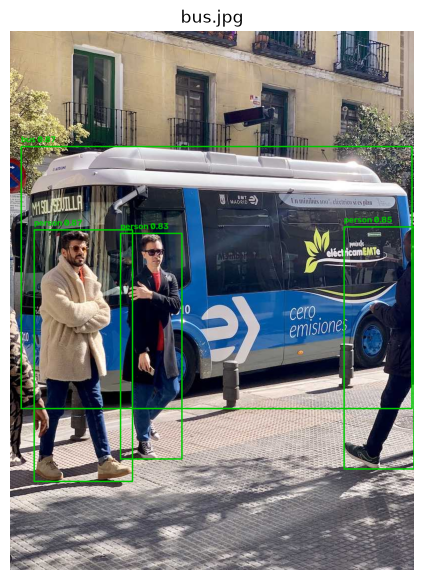

=== zidane.jpg: 2 object(s) detected ===
  [0] person       confidence=0.84  box=(114, 197, 1114, 711)
  [1] person       confidence=0.82  box=(748, 41, 1143, 713)
Summary: 2 person detected



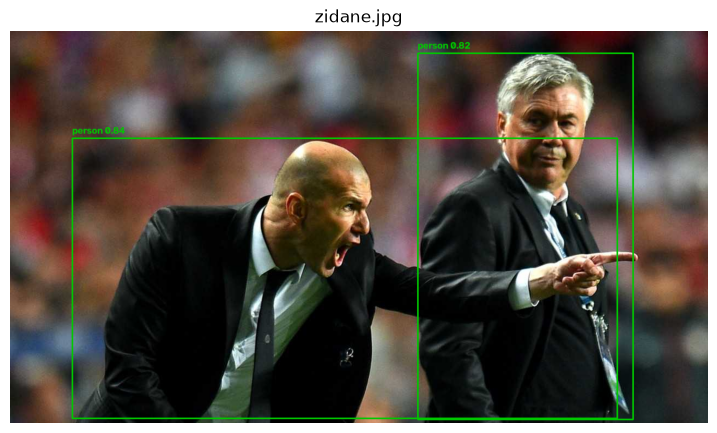

In [6]:
all_detections_by_image = {}

for path in demo_image_paths:
    name = os.path.basename(path)
    image_bgr = cv2.imread(path)

    results = model(image_bgr, conf=CONFIDENCE_THRESHOLD, verbose=False)
    result = results[0]

    detections = parse_detections(result, model)
    all_detections_by_image[name] = detections

    print(f"=== {name}: {len(detections)} object(s) detected ===")
    for i, d in enumerate(detections):
        print(f"  [{i}] {d['label']:<12s} confidence={d['confidence']:.2f}  box={d['box']}")
    print(f"Summary: {summarize_counts(detections)} detected\n")

    annotated = draw_detections(image_bgr, detections)
    show_bgr(annotated, title=name)

## Step 7: Overall object-count summary

Combining the counts across every demo image into a single running report — one
of the extensions suggested for this project.

In [7]:
combined_counts = Counter()
for detections in all_detections_by_image.values():
    combined_counts.update(d["label"] for d in detections)

print("Objects detected across all demo images:")
for label, count in combined_counts.most_common():
    print(f"  {label}: {count}")

total_objects = sum(combined_counts.values())
print(f"\nTotal: {total_objects} object(s) across {len(all_detections_by_image)} image(s)")

Objects detected across all demo images:
  person: 5
  bus: 1

Total: 6 object(s) across 2 image(s)


## Step 8: Ultralytics' built-in `.plot()` shortcut

Manually parsing and drawing boxes (Steps 4-5) is the important part to
understand, but for quick results Ultralytics' `Results` objects also have a
built-in `.plot()` method that returns an already-annotated BGR image in one
line — useful once you understand what it's doing under the hood.

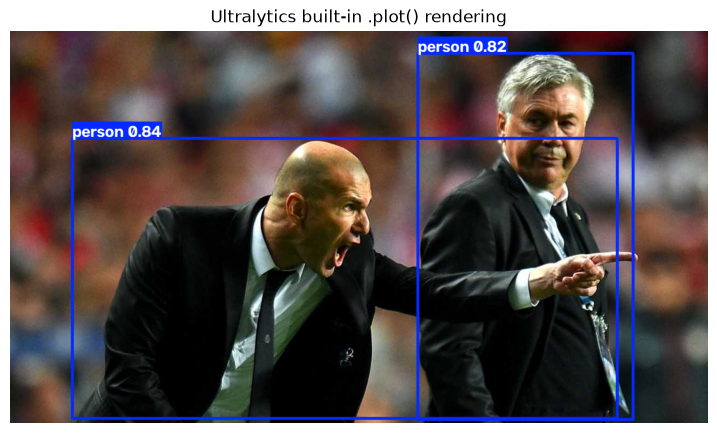

In [8]:
quick_plot = result.plot()  # `result` is still the last demo image's Results object
show_bgr(quick_plot, title="Ultralytics built-in .plot() rendering")

## Step 9: Confidence threshold and class filter in action

Here's a concrete demonstration of the two config knobs from Step 4: raising the
confidence threshold drops borderline detections, and setting a class filter
restricts output to only the object types you care about.

In [9]:
demo_path = demo_image_paths[0]  # bus.jpg
demo_image = cv2.imread(demo_path)
demo_result = model(demo_image, conf=0.05, verbose=False)[0]  # low conf so we see everything the model considered

default_detections = parse_detections(demo_result, model, conf_threshold=CONFIDENCE_THRESHOLD, class_filter=None)
strict_detections = parse_detections(demo_result, model, conf_threshold=0.6, class_filter=None)
person_only_detections = parse_detections(demo_result, model, conf_threshold=CONFIDENCE_THRESHOLD, class_filter={"person"})

print(f"Default threshold ({CONFIDENCE_THRESHOLD}), all classes: {summarize_counts(default_detections)}")
print(f"Stricter threshold (0.6), all classes:      {summarize_counts(strict_detections)}")
print(f"Default threshold, class_filter={{'person'}}:  {summarize_counts(person_only_detections)}")

Default threshold (0.4), all classes: 3 person, 1 bus
Stricter threshold (0.6), all classes:      3 person, 1 bus
Default threshold, class_filter={'person'}:  3 person


## Optional — try it yourself

Upload your own photo from your computer and run the same detection pipeline on
it. This cell only works when the notebook is actually running in Google Colab
(it uses `google.colab.files.upload()`); running it anywhere else just prints a
note and does nothing harmful.

In [10]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import files

    print("Choose an image file (JPG/PNG) to upload:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        image_bgr = cv2.imread(filename)
        if image_bgr is None:
            print(f"Could not read '{filename}' as an image — skipping.")
            continue

        result = model(image_bgr, conf=CONFIDENCE_THRESHOLD, verbose=False)[0]
        detections = parse_detections(result, model)

        print(f"\n=== {filename}: {len(detections)} object(s) detected ===")
        for i, d in enumerate(detections):
            print(f"  [{i}] {d['label']:<12s} confidence={d['confidence']:.2f}  box={d['box']}")
        print(f"Summary: {summarize_counts(detections)} detected")

        annotated = draw_detections(image_bgr, detections)
        show_bgr(annotated, title=filename)
else:
    print("This cell only runs inside Google Colab (it needs google.colab.files.upload()).")
    print("Open this notebook in Colab and re-run this cell to upload and detect your own photo.")

This cell only runs inside Google Colab (it needs google.colab.files.upload()).
Open this notebook in Colab and re-run this cell to upload and detect your own photo.


## Recap

- YOLOv8 detects objects in a single forward pass, making it fast enough for
  real-time use.
- `model(image, conf=...)` returns `Results` objects; each box's `.xyxy`,
  `.conf`, and `.cls` (mapped through `model.names`) give you everything needed
  to manually render or further process detections.
- A confidence threshold and an optional class filter let you tune what counts
  as a "detection" for your use case.
- Remember the limitations above — a bounding box and a label are a pattern
  match, not a verified fact about the world.

**Possible extensions** (see the original project README for more ideas):
- Fine-tune YOLOv8 on a custom dataset for a specialized use case beyond COCO's
  80 classes (`model.train()`).
- Try object tracking across a sequence of frames with `model.track()` so each
  object keeps a consistent ID over time.
- Combine this with a face/expression classifier: use YOLO's "person" boxes to
  crop regions for a downstream model to analyze.